## Topic

Logistic Regression; Precision; Recall; F1; Class Imbalance

先读[Machine Learning Foundations](../Study%20topics/ml-foundations-start-here.html)，再读对应[双语讲义](../Study%20topics/logistic-regression-precision-recall-f1-class-imbalance.html)。

## Question

What is Logistic Regression; Precision; Recall; F1; Class Imbalance, and how would you evaluate it?

本实验中的模型或评估方法是什么？它解决什么问题，又怎样检验效果？

讲义提供Key Terms、直观例子、英文Short Answer及紧接其后的中文回答。先理解问题，再运行下面的代码。


# Logistic Regression; Precision; Recall; F1; Class Imbalance

## Learning Goal

Precision asks how many predicted positives are truly positive; recall asks how many actual positives were found. F1 combines them but omits true negatives. Logistic regression estimates probabilities; a decision threshold translates them into actions.

## Minimal Prerequisites

Basic Python arrays and functions. Run all cells in order; no API key or network data is required. Data are synthetic teaching fixtures, not empirical market evidence.

## Guided Experiment

Move the threshold from .2 to .8 and compare confusion matrices. Explain why recall here has the same coverage idea as retrieval recall but a different denominator.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


0.2 [[125   8]
 [  8   9]]
0.5 [[131   2]
 [  8   9]]
0.8 [[133   0]
 [ 10   7]]


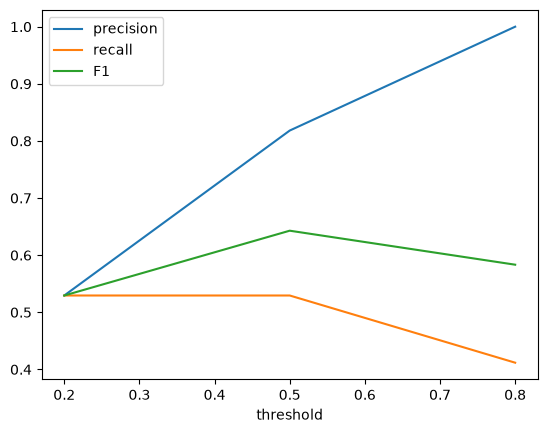

In [2]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,recall_score,f1_score,confusion_matrix
X,y=make_classification(n_samples=500,weights=[.9,.1],random_state=7)
model=LogisticRegression(max_iter=1000).fit(X[:350],y[:350]);p=model.predict_proba(X[350:])[:,1]
rows=[]
for threshold in [.2,.5,.8]:
    pred=p>=threshold;rows.append([threshold,precision_score(y[350:],pred,zero_division=0),recall_score(y[350:],pred),f1_score(y[350:],pred)])
    print(threshold,confusion_matrix(y[350:],pred))
result=pd.DataFrame(rows,columns=["threshold","precision","recall","F1"]);result.plot(x="threshold");plt.show()

## Expected Observations

Higher thresholds usually reduce recall and can increase precision, but finite samples need not show a strictly monotone precision curve.

## Review Experiment

Before changing a parameter, write the direction you expect and why. Change only the parameter named in the guided experiment; rerun from a fresh kernel. Compare the observed result with your prediction. On a later review day, explain the code without reading the answers.

## English Check Questions

1. What quantity is this experiment estimating?
2. What information is available at prediction time?
3. Which observation would invalidate your conclusion?

## Reference Answers

1. Precision asks how many predicted positives are truly positive; recall asks how many actual positives were found. F1 combines them but omits true negatives. Logistic regression estimates probabilities; a decision threshold translates them into actions.
2. Training inputs and their labels must be available before the relevant evaluation origin; preprocessing is fitted on training data only.
3. Higher thresholds usually reduce recall and can increase precision, but finite samples need not show a strictly monotone precision curve.

## Financial Connection

Transfer the timing, metric or deployment contract to the five-day volatility Workbench. A toy experiment verifies mechanics, not trading profitability.

## Sources

- https://scikit-learn.org/stable/common_pitfalls.html
- https://scikit-learn.org/stable/modules/cross_validation.html
- https://scikit-learn.org/stable/modules/model_evaluation.html

[Return to study page](../Study%20topics/logistic-regression-precision-recall-f1-class-imbalance.html)
